#  Homework for Lab 3.7


## 3.7.1 Attention please!


### Datas

In [17]:
from __future__ import unicode_literals, print_function, division
from io import open
import unicodedata
import re
import random

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F

import numpy as np
from torch.utils.data import TensorDataset, DataLoader, RandomSampler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [18]:
PAD_token = 0 
SOS_token = 1
EOS_token = 2

class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {}
        self.word2count = {}
        self.index2word = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>"}
        self.n_words = 3

    def addSentence(self, sentence):
        for word in sentence.split(' '):
            self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

In [19]:

def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

def normalizeString(s):
    s = unicodeToAscii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z!?]+", r" ", s)
    return s.strip()

In [20]:
def readLangs(lang1, lang2, reverse=False):

    # Read the file and split into lines
    lines = open('data/%s-%s.txt' % (lang1, lang2), encoding='utf-8').\
        read().strip().split('\n')

    # Split every line into pairs and normalize
    pairs = [[normalizeString(s) for s in l.split('\t')] for l in lines]

    # Reverse pairs, make Lang instances
    if reverse:
        pairs = [list(reversed(p)) for p in pairs]
        input_lang = Lang(lang2)
        output_lang = Lang(lang1)
    else:
        input_lang = Lang(lang1)
        output_lang = Lang(lang2)

    return input_lang, output_lang, pairs

In [21]:
MAX_LENGTH = 10

eng_prefixes = (
    "i am ", "i m ",
    "he is", "he s ",
    "she is", "she s ",
    "you are", "you re ",
    "we are", "we re ",
    "they are", "they re "
)

def filterPair(p):
    return len(p[0].split(' ')) < MAX_LENGTH and \
        len(p[1].split(' ')) < MAX_LENGTH and \
        p[1].startswith(eng_prefixes)


def filterPairs(pairs):
    return [pair for pair in pairs if filterPair(pair)]

In [22]:
def prepareData(lang1, lang2, reverse=False):
    input_lang, output_lang, pairs = readLangs(lang1, lang2, reverse)
    pairs = filterPairs(pairs)
    for pair in pairs:
        input_lang.addSentence(pair[0])
        output_lang.addSentence(pair[1])
    print(input_lang.name, input_lang.n_words)
    print(output_lang.name, output_lang.n_words)
    return input_lang, output_lang, pairs

input_lang, output_lang, pairs = prepareData('eng', 'fra', True)
print(random.choice(pairs))

fra 4602
eng 2992
['vous etes toutes finies', 'you re all done']


### Model

In [23]:
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_p=0.1):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(input_size, hidden_size, padding_idx=0)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input):
        embedded = self.dropout(self.embedding(input))
        output, hidden = self.gru(embedded)
        return output, hidden

In [24]:
class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=0)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None, teacher_forcing_ratio=0.5):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []
        use_teacher_forcing = target_tensor is not None and random.random() < teacher_forcing_ratio

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden = self.forward_step(decoder_input, decoder_hidden)
            decoder_outputs.append(decoder_output)

            if use_teacher_forcing:
                decoder_input = target_tensor[:, i].unsqueeze(1)
            else:
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        return decoder_outputs, decoder_hidden, None

    def forward_step(self, input, hidden):
        output = self.embedding(input)
        output = F.relu(output)
        output, hidden = self.gru(output, hidden)
        output = self.out(output)
        return output, hidden


### Training and evaluate

In [25]:
def indexesFromSentence(lang, sentence):
    return [lang.word2index[word] for word in sentence.split(' ')]

def tensorFromSentence(lang, sentence):
    indexes = [SOS_token] + indexesFromSentence(lang, sentence) + [EOS_token]
    return torch.tensor(indexes, dtype=torch.long, device=device).view(1, -1)

def tensorsFromPair(pair):
    input_tensor = tensorFromSentence(input_lang, pair[0])
    target_tensor = tensorFromSentence(output_lang, pair[1])
    return (input_tensor, target_tensor)

In [26]:
from torch.utils.data import random_split

def get_dataloader(batch_size):
    input_lang, output_lang, pairs = prepareData('eng', 'fra', True)
    n = len(pairs)
    # Initialize with PAD_token (0)
    input_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)
    target_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)

    for idx, (inp, tgt) in enumerate(pairs):
        inp_ids = [SOS_token] + indexesFromSentence(input_lang, inp) + [EOS_token]
        tgt_ids = [SOS_token] + indexesFromSentence(output_lang, tgt) + [EOS_token]

        # Left padding for input
        if len(inp_ids) <= MAX_LENGTH:
            input_ids[idx, MAX_LENGTH - len(inp_ids):] = inp_ids
        else:
            input_ids[idx, :] = inp_ids[:MAX_LENGTH]

        # Right padding for target
        if len(tgt_ids) <= MAX_LENGTH:
            target_ids[idx, :len(tgt_ids)] = tgt_ids
        else:
            target_ids[idx, :] = tgt_ids[:MAX_LENGTH]

    dataset = TensorDataset(torch.LongTensor(input_ids).to(device),
                            torch.LongTensor(target_ids).to(device))

    train_size = int(0.9 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    train_dataloader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=batch_size)
    val_dataloader = DataLoader(val_dataset, sampler=RandomSampler(val_dataset), batch_size=batch_size)

    return input_lang, output_lang, train_dataloader, val_dataloader

In [27]:
from tqdm.notebook import tqdm

def train_epoch(dataloader, encoder, decoder, encoder_optimizer,
          decoder_optimizer, criterion):

    total_loss = 0
    for data in tqdm(dataloader):
        input_tensor, target_tensor = data

        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, _, _ = decoder(encoder_outputs, encoder_hidden, target_tensor)

        loss = criterion(
            decoder_outputs.view(-1, decoder_outputs.size(-1)),
            target_tensor.view(-1)
        )
        loss.backward()

        encoder_optimizer.step()
        decoder_optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

In [28]:
import matplotlib.pyplot as plt
import numpy as np

def showPlot(history):
    plt.figure()
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.yscale('log')
    plt.legend()
    plt.grid()
    plt.show()

In [29]:
def evaluate(encoder, decoder, sentence, input_lang, output_lang):
    with torch.no_grad():
        input_tensor = tensorFromSentence(input_lang, sentence)

        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, decoder_hidden, decoder_attn = decoder(encoder_outputs, encoder_hidden)

        _, topi = decoder_outputs.topk(1)
        decoded_ids = topi.squeeze()

        decoded_words = []
        for idx in decoded_ids:
            if idx.item() == EOS_token:
                decoded_words.append('<EOS>')
                break
            decoded_words.append(output_lang.index2word[idx.item()])
    return decoded_words, decoder_attn, input_tensor

In [30]:
def train(train_dataloader, val_dataloader, encoder, decoder, num_epochs=20, learning_rate=0.001):

    history = {'train_loss': [], 'val_loss': []}

    encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss(ignore_index=0)

    for epoch in range(1, num_epochs + 1):
        # Training phase
        encoder.train()
        decoder.train()
        train_loss = train_epoch(train_dataloader, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion)
        history['train_loss'].append(train_loss)

        # Validation phase
        encoder.eval()
        decoder.eval()
        val_loss = 0
        with torch.no_grad():
            for data in val_dataloader:
                input_tensor, target_tensor = data
                encoder_outputs, encoder_hidden = encoder(input_tensor)
                decoder_outputs, _, _ = decoder(encoder_outputs, encoder_hidden, target_tensor)

                loss = criterion(
                    decoder_outputs.view(-1, decoder_outputs.size(-1)),
                    target_tensor.view(-1)
                )
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_dataloader)
        history['val_loss'].append(avg_val_loss)

        print(f"Epoch {epoch}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    showPlot(history)
    return history

In [31]:
def evaluateRandomly(encoder, decoder, n=10):
    for i in range(n):
        pair = random.choice(pairs)
        print('>', pair[0])
        print('=', pair[1])
        output_words, _, _ = evaluate(encoder, decoder, pair[0], input_lang, output_lang)
        output_sentence = ' '.join(output_words)
        print('<', output_sentence)
        print('')

In [32]:
hidden_size = 128
batch_size = 32

input_lang, output_lang, train_dataloader, val_dataloader = get_dataloader(batch_size)

# print example sequences
for data in train_dataloader:
    print(data)
    break


fra 4602
eng 2992
[tensor([[   1,    3,    8,  109,    3,  297,  925, 4087,  246,    2],
        [   1,  117,  245,  214,  246,  929,  762,  902,   41,    2],
        [   0,    0,    1,    3,    8, 2581, 2582,   11,  356,    2],
        [   0,    0,    0,    0,    1,   21,  453,  261, 2064,    2],
        [   1,   30,   31,  262,   95, 4055,  100,  243,  644,    2],
        [   0,    0,    0,    0,    1,  351,  453, 1946, 2064,    2],
        [   0,    1,  144,   22,   65,  661,   11,  873, 1685,    2],
        [   0,    0,    0,    0,    1,  117,  214,  187, 2237,    2],
        [   0,    0,    1,    3, 2348,  298, 3136,  114, 3978,    2],
        [   0,    0,    0,    0,    0,    1,   21,  882,  876,    2],
        [   0,    1,  117,  245,  214,  246, 1286,  270, 3226,    2],
        [   0,    0,    1,  122,  122, 4483,  100,  645, 4484,    2],
        [   0,    0,    1,    3,  297,  883,  246,  270, 1943,    2],
        [   0,    0,    0,    0,    0,    1,  122,  125,  369,    2],
 

In [33]:
import os

def save_models(encoder, decoder, filename_prefix="seq2seq_model"):
    """
    Saves the state dictionaries of the encoder and decoder models.
    """
    encoder_path = f"{filename_prefix}_encoder.pth"
    decoder_path = f"{filename_prefix}_decoder.pth"
    torch.save(encoder.state_dict(), encoder_path)
    torch.save(decoder.state_dict(), decoder_path)
    print(f"Encoder model saved to {encoder_path}")
    print(f"Decoder model saved to {decoder_path}")

def load_models(input_size, output_size, hidden_size, filename_prefix="seq2seq_model"):
    """
    Loads the state dictionaries into new encoder and decoder models.
    Returns new instances of EncoderRNN and DecoderRNN with loaded weights.
    """
    encoder_path = f"{filename_prefix}_encoder.pth"
    decoder_path = f"{filename_prefix}_decoder.pth"

    if not os.path.exists(encoder_path) or not os.path.exists(decoder_path):
        print(f"Warning: Model files {encoder_path} or {decoder_path} not found.")
        print("Returning uninitialized models.")
        encoder_instance = EncoderRNN(input_size, hidden_size).to(device)
        decoder_instance = DecoderRNN(hidden_size, output_size).to(device)
        return encoder_instance, decoder_instance

    encoder_instance = EncoderRNN(input_size, hidden_size).to(device)
    decoder_instance = DecoderRNN(hidden_size, output_size).to(device)

    encoder_instance.load_state_dict(torch.load(encoder_path))
    decoder_instance.load_state_dict(torch.load(decoder_path))

    print(f"Encoder model loaded from {encoder_path}")
    print(f"Decoder model loaded from {decoder_path}")
    return encoder_instance, decoder_instance


In [34]:
# this downloads the pre-trained encoder and decoder model weights
!wget "https://cloud.tu-ilmenau.de/public.php/dav/files/MSF6iJJwQoxY3Fr" -O seq2seq_80ep_encoder.pth
!wget "https://cloud.tu-ilmenau.de/public.php/dav/files/bX4wyek849HSjGn" -O seq2seq_80ep_decoder.pth

--2026-06-10 22:02:14--  https://cloud.tu-ilmenau.de/public.php/dav/files/MSF6iJJwQoxY3Fr
Resolving cloud.tu-ilmenau.de (cloud.tu-ilmenau.de)... 141.24.186.192
Connecting to cloud.tu-ilmenau.de (cloud.tu-ilmenau.de)|141.24.186.192|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2754893 (2.6M) [application/octet-stream]
Saving to: ‘seq2seq_80ep_encoder.pth’

seq2seq_80ep_encode 100%[===================>]   2.63M  17.3MB/s    in 0.2s    

2026-06-10 22:02:16 (17.3 MB/s) - ‘seq2seq_80ep_encoder.pth’ saved [2754893/2754893]

--2026-06-10 22:02:16--  https://cloud.tu-ilmenau.de/public.php/dav/files/bX4wyek849HSjGn
Resolving cloud.tu-ilmenau.de (cloud.tu-ilmenau.de)... 141.24.186.192
Connecting to cloud.tu-ilmenau.de (cloud.tu-ilmenau.de)|141.24.186.192|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3806101 (3.6M) [application/octet-stream]
Saving to: ‘seq2seq_80ep_decoder.pth’

seq2seq_80ep_decode 100%[===================>]   3.63M  19.9M

In [35]:

encoder = EncoderRNN(input_lang.n_words, hidden_size).to(device)
decoder = DecoderRNN(hidden_size, output_lang.n_words).to(device)

print("Initialized fresh encoder and decoder models")
print(f"Encoder vocabulary size: {input_lang.n_words}")
print(f"Decoder vocabulary size: {output_lang.n_words}")
print(f"Hidden size: {hidden_size}\n")


Initialized fresh encoder and decoder models
Encoder vocabulary size: 4602
Decoder vocabulary size: 2992
Hidden size: 128



  0%|          | 0/322 [00:00<?, ?it/s]

Epoch 1/20 | Train Loss: 3.7061 | Val Loss: 3.2463


  0%|          | 0/322 [00:00<?, ?it/s]

Epoch 2/20 | Train Loss: 2.9368 | Val Loss: 2.7629


  0%|          | 0/322 [00:00<?, ?it/s]

...

Epoch 18/20 | Train Loss: 1.2296 | Val Loss: 1.8845


  0%|          | 0/322 [00:00<?, ?it/s]

Epoch 19/20 | Train Loss: 1.1746 | Val Loss: 1.9013


  0%|          | 0/322 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 1.1700 | Val Loss: 1.9113


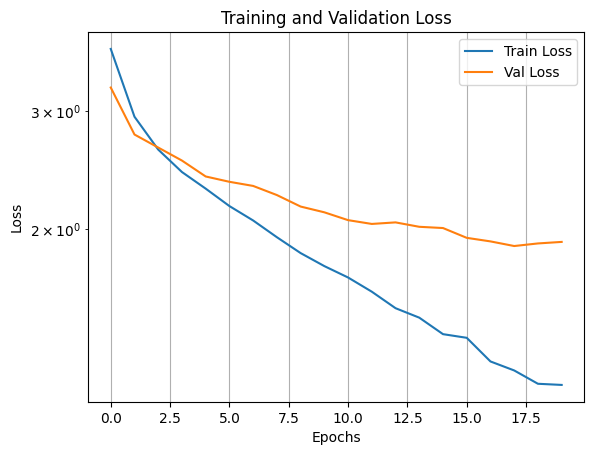

In [36]:
history = train(train_dataloader, val_dataloader, encoder, decoder, num_epochs=20)

## Training the Model


In [37]:
encoder = EncoderRNN(input_lang.n_words, hidden_size).to(device)
decoder = DecoderRNN(hidden_size, output_lang.n_words).to(device)

# Print model info
encoder_params = sum(p.numel() for p in encoder.parameters())
decoder_params = sum(p.numel() for p in decoder.parameters())
total_params = encoder_params + decoder_params

print(f"Model Architecture:")
print(f"Encoder parameters: {encoder_params:,}")
print(f"Decoder parameters: {decoder_params:,}")
print(f"Total parameters: {total_params:,}")
print(f"Hidden size: {hidden_size}")
print(f"Max sequence length: {MAX_LENGTH}\n")


Model Architecture:
Encoder parameters: 688,128
Decoder parameters: 868,016
Total parameters: 1,556,144
Hidden size: 128
Max sequence length: 10



training for 20 epochs
Learning rate: 0.001



  0%|          | 0/322 [00:00<?, ?it/s]

Epoch 1/20 | Train Loss: 3.7373 | Val Loss: 3.2721


  0%|          | 0/322 [00:00<?, ?it/s]

Epoch 2/20 | Train Loss: 2.9845 | Val Loss: 2.7927


...

Epoch 18/20 | Train Loss: 1.1365 | Val Loss: 1.8357


  0%|          | 0/322 [00:00<?, ?it/s]

Epoch 19/20 | Train Loss: 1.1087 | Val Loss: 1.9041


  0%|          | 0/322 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 1.0103 | Val Loss: 1.8547


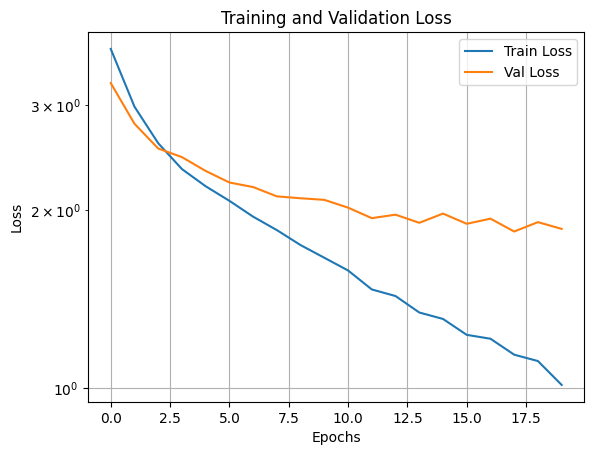

Training Complete
Final Training Loss: 1.0103
Final Validation Loss: 1.8547
Best Validation Loss: 1.8357 (Epoch 18)


In [38]:
# Train the model for 20 epochs
num_epochs = 20
learning_rate = 0.001

print(f"training for {num_epochs} epochs")
print(f"Learning rate: {learning_rate}\n")

history = train(train_dataloader, val_dataloader, encoder, decoder, num_epochs=num_epochs, learning_rate=learning_rate)

# Print final results
print(f"Training Complete")
print(f"Final Training Loss: {history['train_loss'][-1]:.4f}")
print(f"Final Validation Loss: {history['val_loss'][-1]:.4f}")
print(f"Best Validation Loss: {min(history['val_loss']):.4f} (Epoch {history['val_loss'].index(min(history['val_loss'])) + 1})")


In [39]:
# Evaluation: Set models to eval mode and test on random examples
encoder.eval()
decoder.eval()

print("Sample Translations (Random Test Sentences)")
evaluateRandomly(encoder, decoder, n=5)


Sample Translations (Random Test Sentences)
> nous sommes pour ainsi dire pretes
= we re about ready
< <SOS> we re here to protect tom <EOS>

> je suis choquee
= i m shocked
< <SOS> i m shocked <EOS>

> ce sont tous des touristes
= they re all tourists
< <SOS> they re all tourists <EOS>

> vous etes tres talentueux
= you re very talented
< <SOS> you re very nice <EOS>

> nous sommes maintenant pretes
= we re ready now
< <SOS> we re ready for this <EOS>



## 3.7.2 Teacher-Forcing and Scheduled Sampling

In this section, we analyze the impact of different teacher-forcing ratios on:
- **Training convergence**: How quickly the model learns
- **Translation quality**: How well the model generates translations
- **Model stability**: Differences between training and inference behavior

We will train three models with teacher-forcing ratios of **0%**, **50%**, and **100%** for **50 epochs** each, using identical architecture and hyperparameters to ensure a fair comparison.


In [40]:
def train_epoch_with_ratio(dataloader, encoder, decoder, encoder_optimizer,
                           decoder_optimizer, criterion, teacher_forcing_ratio=0.5):

    total_loss = 0
    for data in tqdm(dataloader):
        input_tensor, target_tensor = data

        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        encoder_outputs, encoder_hidden = encoder(input_tensor)

        batch_size = input_tensor.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []
        
        # Use teacher forcing with the specified ratio
        use_teacher_forcing = random.random() < teacher_forcing_ratio
        
        for i in range(MAX_LENGTH):
            if use_teacher_forcing:
                decoder_output, decoder_hidden = decoder.forward_step(decoder_input, decoder_hidden)
                decoder_outputs.append(decoder_output)
                decoder_input = target_tensor[:, i].unsqueeze(1)
            else:
                decoder_output, decoder_hidden = decoder.forward_step(decoder_input, decoder_hidden)
                decoder_outputs.append(decoder_output)
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()
        
        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        
        loss = criterion(
            decoder_outputs.view(-1, decoder_outputs.size(-1)),
            target_tensor.view(-1)
        )
        loss.backward()

        encoder_optimizer.step()
        decoder_optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def train_with_teacher_forcing_ratio(train_dataloader, val_dataloader, encoder, decoder, 
                                     teacher_forcing_ratio=0.5, num_epochs=50, learning_rate=0.001):

    history = {'train_loss': [], 'val_loss': []}

    encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss(ignore_index=0)

    for epoch in range(1, num_epochs + 1):
        # Training 
        encoder.train()
        decoder.train()
        train_loss = train_epoch_with_ratio(train_dataloader, encoder, decoder, 
                                           encoder_optimizer, decoder_optimizer, criterion, 
                                           teacher_forcing_ratio)
        history['train_loss'].append(train_loss)

        # Validation 
        encoder.eval()
        decoder.eval()
        val_loss = 0
        with torch.no_grad():
            for data in val_dataloader:
                input_tensor, target_tensor = data
                encoder_outputs, encoder_hidden = encoder(input_tensor)
                decoder_outputs, _, _ = decoder(encoder_outputs, encoder_hidden, target_tensor)

                loss = criterion(
                    decoder_outputs.view(-1, decoder_outputs.size(-1)),
                    target_tensor.view(-1)
                )
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_dataloader)
        history['val_loss'].append(avg_val_loss)

        if epoch % 5 == 0:
            print(f"Epoch {epoch}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    return history


In [41]:
teacher_forcing_ratios = [0.0, 0.5, 1.0]  # 0%, 50%, 100%
num_epochs_comparison = 50
learning_rate = 0.001

all_histories = {}
all_models = {}

print("Training models with different teacher-forcing ratios")
print(f"Epochs: {num_epochs_comparison}")
print(f"Learning rate: {learning_rate}")
print(f"Hidden size: {hidden_size}")
print(f"Batch size: {batch_size}\n")

# Train three models with different teacher-forcing ratios
for tf_ratio in teacher_forcing_ratios:
    print(f"Training with Teacher-Forcing Ratio: {tf_ratio*100:.0f}%")
    
    # Initialize fresh encoder and decoder
    encoder_tf = EncoderRNN(input_lang.n_words, hidden_size).to(device)
    decoder_tf = DecoderRNN(hidden_size, output_lang.n_words).to(device)
    
    # Train model
    history_tf = train_with_teacher_forcing_ratio(
        train_dataloader, val_dataloader, encoder_tf, decoder_tf,
        teacher_forcing_ratio=tf_ratio, num_epochs=num_epochs_comparison,
        learning_rate=learning_rate
    )
    
    # Store results
    key = f"TF_{int(tf_ratio*100)}%"
    all_histories[key] = history_tf
    all_models[key] = (encoder_tf, decoder_tf)
    
    print(f"\nFinal Results for Teacher-Forcing {tf_ratio*100:.0f}%:")
    print(f"Final Train Loss: {history_tf['train_loss'][-1]:.4f}")
    print(f"Final Val Loss: {history_tf['val_loss'][-1]:.4f}")
    print(f"  Best Val Loss: {min(history_tf['val_loss']):.4f} (Epoch {history_tf['val_loss'].index(min(history_tf['val_loss'])) + 1})")


Training models with different teacher-forcing ratios
Epochs: 50
Learning rate: 0.001
Hidden size: 128
Batch size: 32

Training with Teacher-Forcing Ratio: 0%


  0%|          | 0/322 [00:00<?, ?it/s]

  0%|          | 0/322 [00:00<?, ?it/s]

  0%|          | 0/322 [00:00<?, ?it/s]

  0%|          | 0/322 [00:00<?, ?it/s]

...

  0%|          | 0/322 [00:00<?, ?it/s]

  0%|          | 0/322 [00:00<?, ?it/s]

  0%|          | 0/322 [00:00<?, ?it/s]

  0%|          | 0/322 [00:00<?, ?it/s]

Epoch 50/50 | Train Loss: 0.2089 | Val Loss: 2.5578

Final Results for Teacher-Forcing 100%:
Final Train Loss: 0.2089
Final Val Loss: 2.5578
  Best Val Loss: 2.3412 (Epoch 26)


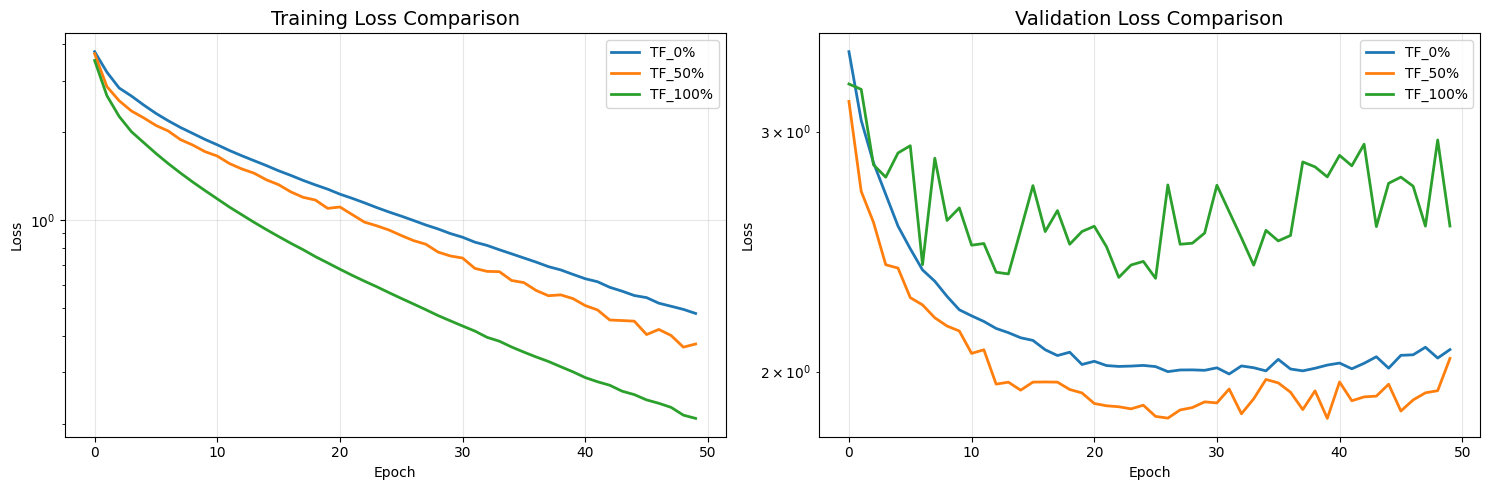

COMPARISON SUMMARY
Teacher-Forcing Ratio     Final Train Loss     Final Val Loss       Best Val Loss       
0%                        0.4780               2.0755               1.9917              
50%                       0.3757               2.0448               1.8477              
100%                      0.2089               2.5578               2.3412              


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for key, history in all_histories.items():
    axes[0].plot(history['train_loss'], label=key, linewidth=2)
axes[0].set_title('Training Loss Comparison', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for key, history in all_histories.items():
    axes[1].plot(history['val_loss'], label=key, linewidth=2)
axes[1].set_title('Validation Loss Comparison', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("COMPARISON SUMMARY")
print(f"{'Teacher-Forcing Ratio':<25} {'Final Train Loss':<20} {'Final Val Loss':<20} {'Best Val Loss':<20}")

for key, history in all_histories.items():
    tf_ratio = key.split('_')[1]
    final_train = history['train_loss'][-1]
    final_val = history['val_loss'][-1]
    best_val = min(history['val_loss'])
    print(f"{tf_ratio:<25} {final_train:<20.4f} {final_val:<20.4f} {best_val:<20.4f}")


In [43]:
test_sentences = [random.choice(pairs) for _ in range(3)]

print("QUALITATIVE EVALUATION: Translation Examples")

for test_idx, (src, tgt) in enumerate(test_sentences, 1):
    print(f"\nExample {test_idx}:")
    print(f"  Input:  {src}")
    print(f"  Target: {tgt}")
    
    for key, (encoder_model, decoder_model) in all_models.items():
        encoder_model.eval()
        decoder_model.eval()
        
        output_words, _, _ = evaluate(encoder_model, decoder_model, src, input_lang, output_lang)
        output_sentence = ' '.join(output_words)
        print(f"  {key:<12}: {output_sentence}")


QUALITATIVE EVALUATION: Translation Examples

Example 1:
  Input:  je suis incroyablement fatigue
  Target: i m incredibly tired
  TF_0%       : <SOS> i m kind too of it <EOS>
  TF_50%      : <SOS> i m smarter than hear that <EOS>
  TF_100%     : <SOS> i m one of your students <EOS>

Example 2:
  Input:  je suis egalement occupee
  Target: i m busy too
  TF_0%       : <SOS> i m busy too drunk <EOS>
  TF_50%      : <SOS> i m busy too fast <EOS>
  TF_100%     : <SOS> i m very pleased to my house <EOS>

Example 3:
  Input:  j en ai marre de mentir
  Target: i m sick of lying
  TF_0%       : <SOS> i m sick of this game <EOS>
  TF_50%      : <SOS> i m sick of this game <EOS>
  TF_100%     : <SOS> i m sick of hearing it <EOS>


Summary:
- 100%: Fastest
- 50%: middle
- 0%: Slow training


## 3.7.3 Luong Dot-Product Attention vs Bahdanau Attention


In [44]:
class LuongAttention(nn.Module):
    def __init__(self, hidden_size):
        super(LuongAttention, self).__init__()
        self.hidden_size = hidden_size

    def forward(self, decoder_hidden, encoder_outputs):
        decoder_hidden = decoder_hidden.transpose(0, 1)
        scores = torch.bmm(encoder_outputs, decoder_hidden.transpose(1, 2)).squeeze(2)
        attention_weights = F.softmax(scores, dim=1)
        context = torch.bmm(attention_weights.unsqueeze(1), encoder_outputs)
        return context, attention_weights


class LuongAttnDecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_p=0.1):
        super(LuongAttnDecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=0)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.attention = LuongAttention(hidden_size)
        self.attn_combine = nn.Linear(hidden_size * 2, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None, teacher_forcing_ratio=0.5):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []
        use_teacher_forcing = target_tensor is not None and random.random() < teacher_forcing_ratio

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden = self.forward_step(decoder_input, decoder_hidden, encoder_outputs)
            decoder_outputs.append(decoder_output)

            if use_teacher_forcing:
                decoder_input = target_tensor[:, i].unsqueeze(1)
            else:
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        return decoder_outputs, decoder_hidden, None

    def forward_step(self, input, hidden, encoder_outputs):
        embedded = self.dropout(self.embedding(input))
        output, hidden = self.gru(embedded, hidden)
        context, _ = self.attention(hidden, encoder_outputs)
        combined = torch.cat((output, context), dim=2)
        output = torch.tanh(self.attn_combine(combined))
        output = self.out(output)
        return output, hidden


class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()
        self.W1 = nn.Linear(hidden_size, hidden_size)
        self.W2 = nn.Linear(hidden_size, hidden_size)
        self.V = nn.Linear(hidden_size, 1)

    def forward(self, decoder_hidden, encoder_outputs):
        hidden_with_time_axis = decoder_hidden.transpose(0, 1)
        score = self.V(torch.tanh(self.W1(encoder_outputs) + self.W2(hidden_with_time_axis)))
        attention_weights = F.softmax(score, dim=1)
        context = torch.bmm(attention_weights.transpose(1, 2), encoder_outputs)
        return context, attention_weights.squeeze(2)


class BahdanauAttnDecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_p=0.1):
        super(BahdanauAttnDecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=0)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.attention = BahdanauAttention(hidden_size)
        self.attn_combine = nn.Linear(hidden_size * 2, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None, teacher_forcing_ratio=0.5):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []
        use_teacher_forcing = target_tensor is not None and random.random() < teacher_forcing_ratio

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden = self.forward_step(decoder_input, decoder_hidden, encoder_outputs)
            decoder_outputs.append(decoder_output)

            if use_teacher_forcing:
                decoder_input = target_tensor[:, i].unsqueeze(1)
            else:
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        return decoder_outputs, decoder_hidden, None

    def forward_step(self, input, hidden, encoder_outputs):
        embedded = self.dropout(self.embedding(input))
        output, hidden = self.gru(embedded, hidden)
        context, _ = self.attention(hidden, encoder_outputs)
        combined = torch.cat((output, context), dim=2)
        output = torch.tanh(self.attn_combine(combined))
        output = self.out(output)
        return output, hidden

In [45]:
def train_attention_epoch(dataloader, encoder, decoder, encoder_optimizer,
                          decoder_optimizer, criterion, teacher_forcing_ratio=0.5):
    total_loss = 0
    for data in tqdm(dataloader):
        input_tensor, target_tensor = data

        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, _, _ = decoder(encoder_outputs, encoder_hidden, target_tensor, teacher_forcing_ratio)

        loss = criterion(
            decoder_outputs.view(-1, decoder_outputs.size(-1)),
            target_tensor.view(-1)
        )
        loss.backward()

        encoder_optimizer.step()
        decoder_optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def train_attention_model(train_dataloader, val_dataloader, encoder, decoder,
                          num_epochs=20, learning_rate=0.001, teacher_forcing_ratio=0.5):
    history = {'train_loss': [], 'val_loss': []}
    encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss(ignore_index=0)

    for epoch in range(1, num_epochs + 1):
        encoder.train()
        decoder.train()
        train_loss = train_attention_epoch(train_dataloader, encoder, decoder,
                                           encoder_optimizer, decoder_optimizer, criterion,
                                           teacher_forcing_ratio)
        history['train_loss'].append(train_loss)

        encoder.eval()
        decoder.eval()
        val_loss = 0
        with torch.no_grad():
            for data in val_dataloader:
                input_tensor, target_tensor = data
                encoder_outputs, encoder_hidden = encoder(input_tensor)
                decoder_outputs, _, _ = decoder(encoder_outputs, encoder_hidden, target_tensor)
                loss = criterion(
                    decoder_outputs.view(-1, decoder_outputs.size(-1)),
                    target_tensor.view(-1)
                )
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_dataloader)
        history['val_loss'].append(avg_val_loss)

        print(f"Epoch {epoch}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    return history


def evaluate_attention(encoder, decoder, sentence, input_lang, output_lang):
    with torch.no_grad():
        input_tensor = tensorFromSentence(input_lang, sentence)
        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, _, _ = decoder(encoder_outputs, encoder_hidden)

        _, topi = decoder_outputs.topk(1)
        decoded_ids = topi.squeeze()

        decoded_words = []
        for idx in decoded_ids:
            if idx.item() == EOS_token:
                decoded_words.append('<EOS>')
                break
            decoded_words.append(output_lang.index2word[idx.item()])
    return decoded_words


def evaluateRandomlyAttention(encoder, decoder, n=5, input_lang=None, output_lang=None):
    for i in range(n):
        pair = random.choice(pairs)
        print('>', pair[0])
        print('=', pair[1])
        output_words = evaluate_attention(encoder, decoder, pair[0], input_lang, output_lang)
        output_sentence = ' '.join(output_words)
        print('<', output_sentence)
        print('')

In [49]:
attention_hidden_size = 128
attention_batch_size = 32
attention_epochs = 20
attention_lr = 0.001

input_lang, output_lang, train_dataloader, val_dataloader = get_dataloader(attention_batch_size)

encoder_luong = EncoderRNN(input_lang.n_words, attention_hidden_size).to(device)
decoder_luong = LuongAttnDecoderRNN(attention_hidden_size, output_lang.n_words).to(device)
history_luong = train_attention_model(train_dataloader, val_dataloader, encoder_luong, decoder_luong,
                                      num_epochs=attention_epochs, learning_rate=attention_lr,
                                      teacher_forcing_ratio=0.5)

encoder_bahdanau = EncoderRNN(input_lang.n_words, attention_hidden_size).to(device)
decoder_bahdanau = BahdanauAttnDecoderRNN(attention_hidden_size, output_lang.n_words).to(device)
history_bahdanau = train_attention_model(train_dataloader, val_dataloader, encoder_bahdanau, decoder_bahdanau,
                                          num_epochs=attention_epochs, learning_rate=attention_lr,
                                          teacher_forcing_ratio=0.5)

fra 4602
eng 2992


  0%|          | 0/322 [00:00<?, ?it/s]

Epoch 1/20 | Train Loss: 3.6662 | Val Loss: 2.9559


  0%|          | 0/322 [00:00<?, ?it/s]

Epoch 2/20 | Train Loss: 2.7438 | Val Loss: 2.6559


...

Epoch 18/20 | Train Loss: 0.5254 | Val Loss: 1.2754


  0%|          | 0/322 [00:00<?, ?it/s]

Epoch 19/20 | Train Loss: 0.4738 | Val Loss: 1.3262


  0%|          | 0/322 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 0.4441 | Val Loss: 1.2989


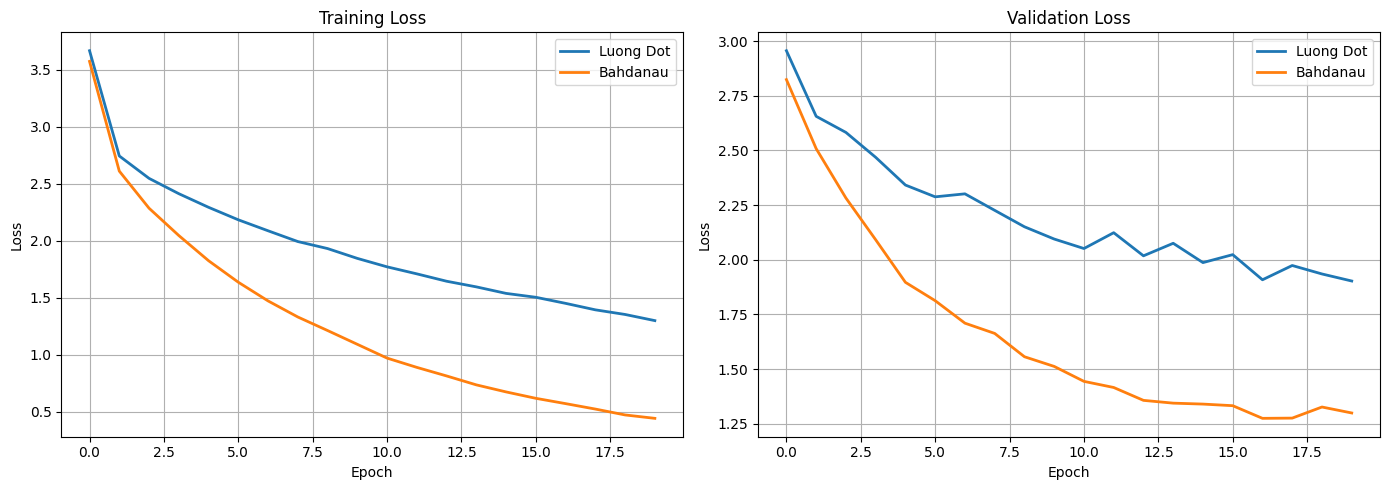

Model                Final Train     Final Val       Best Val       
Luong Dot            1.3006          1.9025          1.9025         
Bahdanau             0.4441          1.2989          1.2744         


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_luong['train_loss'], label='Luong Dot', linewidth=2)
axes[0].plot(history_bahdanau['train_loss'], label='Bahdanau', linewidth=2)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_luong['val_loss'], label='Luong Dot', linewidth=2)
axes[1].plot(history_bahdanau['val_loss'], label='Bahdanau', linewidth=2)
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"{'Model':<20} {'Final Train':<15} {'Final Val':<15} {'Best Val':<15}")
print(f"{'Luong Dot':<20} {history_luong['train_loss'][-1]:<15.4f} {history_luong['val_loss'][-1]:<15.4f} {min(history_luong['val_loss']):<15.4f}")
print(f"{'Bahdanau':<20} {history_bahdanau['train_loss'][-1]:<15.4f} {history_bahdanau['val_loss'][-1]:<15.4f} {min(history_bahdanau['val_loss']):<15.4f}")

In [51]:
print('Sample translations for Luong dot-product attention:')
encoder_luong.eval()
decoder_luong.eval()
evaluateRandomlyAttention(encoder_luong, decoder_luong, n=5, input_lang=input_lang, output_lang=output_lang)

print('Sample translations for Bahdanau attention:')
encoder_bahdanau.eval()
decoder_bahdanau.eval()
evaluateRandomlyAttention(encoder_bahdanau, decoder_bahdanau, n=5, input_lang=input_lang, output_lang=output_lang)

Sample translations for Luong dot-product attention:
> j apprends aussi le francais
= i m also learning french
< <SOS> i m calling the my s <EOS>

> je suis desolee je n ai pas saisi cela
= i m sorry i didn t catch that
< <SOS> i m sorry i didn t hear you <EOS>

> je suis triste sans vous
= i m sad without you
< <SOS> i m glad i came <EOS>

> je ne suis pas plus intelligent que lui
= i m not as intelligent as he is
< <SOS> i m not as smart as you <EOS>

> tu es fort sceptique
= you re very skeptical
< <SOS> you re disappointed than i am <EOS>

Sample translations for Bahdanau attention:
> je suis observe
= i m being watched
< <SOS> i m in way to have <EOS>

> je suis heureuse de vous avoir invitees
= i m glad i invited you
< <SOS> i m glad i invited you <EOS>

> nous sommes en route
= we re on our way
< <SOS> we re in way way over <EOS>

> j habite avec mon oncle
= i am living with my uncle
< <SOS> i m ashamed with my uncle s <EOS>

> vous n etes pas censee etre la dedans
= you re not 

## 3.7.5 Text Autoencoders: Pre-trained Encoder vs Feedforward Autoencoder

In [52]:
def get_autoencoder_dataloader(batch_size):
    auto_input_lang, _, auto_pairs = prepareData('eng', 'fra', True)
    n = len(auto_pairs)
    input_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)
    target_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)

    for idx, (inp, _) in enumerate(auto_pairs):
        inp_ids = [SOS_token] + indexesFromSentence(auto_input_lang, inp) + [EOS_token]
        if len(inp_ids) <= MAX_LENGTH:
            input_ids[idx, MAX_LENGTH - len(inp_ids):] = inp_ids
            target_ids[idx, :len(inp_ids)] = inp_ids
        else:
            input_ids[idx, :] = inp_ids[:MAX_LENGTH]
            target_ids[idx, :] = inp_ids[:MAX_LENGTH]

    dataset = TensorDataset(torch.LongTensor(input_ids).to(device),
                            torch.LongTensor(target_ids).to(device))
    train_size = int(0.9 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    train_loader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=batch_size)
    val_loader = DataLoader(val_dataset, sampler=RandomSampler(val_dataset), batch_size=batch_size)
    return auto_input_lang, train_loader, val_loader


auto_input_lang, ae_train_loader, ae_val_loader = get_autoencoder_dataloader(batch_size)
print(f'Autoencoder French vocab size: {auto_input_lang.n_words}')

fra 4602
eng 2992
Autoencoder French vocab size: 4602


In [53]:
class FeedforwardAutoencoder(nn.Module):
    def __init__(self, vocab_size, embed_size=128, latent_size=256):
        super(FeedforwardAutoencoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(MAX_LENGTH * embed_size, latent_size),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_size, MAX_LENGTH * embed_size),
            nn.ReLU()
        )
        self.out = nn.Linear(embed_size, vocab_size)

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        z = self.encoder(x)
        x_rec = self.decoder(z).view(-1, MAX_LENGTH, x.size(2))
        logits = self.out(x_rec)
        return logits


class Seq2SeqAutoencoder(nn.Module):
    def __init__(self, encoder, decoder):
        super(Seq2SeqAutoencoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, input_tensor, target_tensor=None, teacher_forcing_ratio=0.5):
        with torch.no_grad():
            encoder_outputs, encoder_hidden = self.encoder(input_tensor)
        decoder_outputs, _, _ = self.decoder(encoder_outputs, encoder_hidden,
                                            target_tensor, teacher_forcing_ratio)
        return decoder_outputs

In [57]:
def train_feedforward_autoencoder(train_loader, val_loader, model, optimizer, criterion, num_epochs=20):
    history = {'train_loss': [], 'val_loss': []}
    for epoch in range(1, num_epochs + 1):
        model.train()
        train_loss = 0
        for input_tensor, target_tensor in tqdm(train_loader, desc=f'FFAE Epoch {epoch}'):
            optimizer.zero_grad()
            outputs = model(input_tensor)
            loss = criterion(outputs.view(-1, outputs.size(-1)), target_tensor.view(-1))
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        history['train_loss'].append(train_loss / len(train_loader))

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for input_tensor, target_tensor in val_loader:
                outputs = model(input_tensor)
                loss = criterion(outputs.view(-1, outputs.size(-1)), target_tensor.view(-1))
                val_loss += loss.item()
        history['val_loss'].append(val_loss / len(val_loader))
        print(f'Epoch {epoch}/{num_epochs} | FF AE Train Loss: {history["train_loss"][-1]:.4f} | Val Loss: {history["val_loss"][-1]:.4f}')
    return history


def train_seq2seq_autoencoder(train_loader, val_loader, encoder, decoder, num_epochs=20, learning_rate=0.001, teacher_forcing_ratio=0.5):
    for param in encoder.parameters():
        param.requires_grad = False
    encoder.eval()
    decoder.train()

    optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, num_epochs + 1):
        train_loss = 0
        for input_tensor, target_tensor in tqdm(train_loader, desc=f'Seq2Seq AE Epoch {epoch}'):
            optimizer.zero_grad()
            outputs = decoder(*encoder(input_tensor), target_tensor, teacher_forcing_ratio)
            outputs = outputs[0]
            loss = criterion(outputs.view(-1, outputs.size(-1)), target_tensor.view(-1))
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        history['train_loss'].append(train_loss / len(train_loader))

        decoder.eval()
        val_loss = 0
        with torch.no_grad():
            for input_tensor, target_tensor in val_loader:
                outputs = decoder(*encoder(input_tensor), target_tensor, teacher_forcing_ratio=0.0)[0]
                loss = criterion(outputs.view(-1, outputs.size(-1)), target_tensor.view(-1))
                val_loss += loss.item()
        history['val_loss'].append(val_loss / len(val_loader))
        print(f'Epoch {epoch}/{num_epochs} | Seq2Seq AE Train Loss: {history["train_loss"][-1]:.4f} | Val Loss: {history["val_loss"][-1]:.4f}')
        decoder.train()
    return history

In [58]:
seq2seq_decoder = DecoderRNN(hidden_size, auto_input_lang.n_words).to(device)
seq2seq_ae = Seq2SeqAutoencoder(encoder_luong, seq2seq_decoder)
ff_ae = FeedforwardAutoencoder(auto_input_lang.n_words, embed_size=128, latent_size=256).to(device)

ff_optimizer = optim.Adam(ff_ae.parameters(), lr=0.001)
ff_criterion = nn.CrossEntropyLoss(ignore_index=0)

ff_history = train_feedforward_autoencoder(ae_train_loader, ae_val_loader, ff_ae, ff_optimizer, ff_criterion, num_epochs=20)

seq2seq_history = train_seq2seq_autoencoder(ae_train_loader, ae_val_loader, encoder_luong, seq2seq_decoder, num_epochs=20, learning_rate=0.001, teacher_forcing_ratio=0.5)

print('\nModel sizes:')
ff_params = sum(p.numel() for p in ff_ae.parameters())
seq2seq_params = sum(p.numel() for p in encoder_luong.parameters()) + sum(p.numel() for p in seq2seq_decoder.parameters())
print(f'Feedforward AE params: {ff_params:,}')
print(f'Seq2Seq AE params: {seq2seq_params:,}')

FFAE Epoch 1:   0%|          | 0/322 [00:00<?, ?it/s]

Epoch 1/20 | FF AE Train Loss: 3.0381 | Val Loss: 2.3924


FFAE Epoch 2:   0%|          | 0/322 [00:00<?, ?it/s]

Epoch 2/20 | FF AE Train Loss: 1.8950 | Val Loss: 2.0048


FFAE Epoch 3:   0%|          | 0/322 [00:00<?, ?it/s]

...

Epoch 18/20 | Seq2Seq AE Train Loss: 1.2049 | Val Loss: 2.3306


Seq2Seq AE Epoch 19:   0%|          | 0/322 [00:00<?, ?it/s]

Epoch 19/20 | Seq2Seq AE Train Loss: 1.1842 | Val Loss: 2.3266


Seq2Seq AE Epoch 20:   0%|          | 0/322 [00:00<?, ?it/s]

Epoch 20/20 | Seq2Seq AE Train Loss: 1.1443 | Val Loss: 2.3065

Model sizes:
Feedforward AE params: 1,839,610
Seq2Seq AE params: 1,969,914


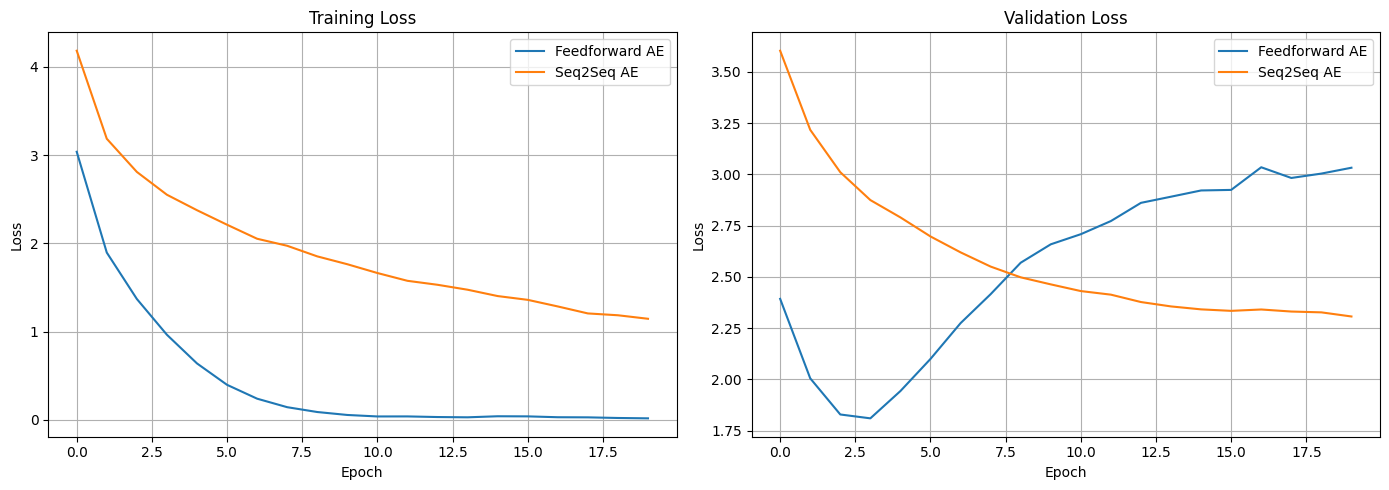

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(ff_history['train_loss'], label='Feedforward AE')
axes[0].plot(seq2seq_history['train_loss'], label='Seq2Seq AE')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(ff_history['val_loss'], label='Feedforward AE')
axes[1].plot(seq2seq_history['val_loss'], label='Seq2Seq AE')
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [62]:
def reconstruct_sentence(model, input_sentence, lang, seq2seq=False):
    input_tensor = tensorFromSentence(lang, input_sentence).squeeze()

    # Pad or truncate to MAX_LENGTH
    if len(input_tensor) < MAX_LENGTH:
        padding = torch.full(
            (MAX_LENGTH - len(input_tensor),),
            PAD_token,
            dtype=torch.long,
            device=input_tensor.device
        )
        input_tensor = torch.cat([input_tensor, padding])

    input_tensor = input_tensor[:MAX_LENGTH]

    # Add batch dimension
    input_tensor = input_tensor.unsqueeze(0)
    with torch.no_grad():
        if seq2seq:
            outputs = model.decoder(*model.encoder(input_tensor), None, teacher_forcing_ratio=0.0)[0]
            _, topi = outputs.topk(1)
            decoded_ids = topi.squeeze()
        else:
            logits = model(input_tensor)
            _, topi = logits.topk(1)
            decoded_ids = topi.squeeze()
    decoded_words = []
    for idx in decoded_ids:
        if idx.item() == EOS_token:
            decoded_words.append('<EOS>')
            break
        decoded_words.append(lang.index2word.get(idx.item(), '<UNK>'))
    return ' '.join(decoded_words)

print('Reconstruction examples:')
for i in range(5):
    inp, _ = random.choice(pairs)
    reconstructed_ff = reconstruct_sentence(ff_ae, inp, auto_input_lang, seq2seq=False)
    reconstructed_ss = reconstruct_sentence(seq2seq_ae, inp, auto_input_lang, seq2seq=True)
    print(f'Input: {inp}')
    print(f'Feedforward AE: {reconstructed_ff}')
    print(f'Seq2Seq AE:   {reconstructed_ss}')


Reconstruction examples:
Input: elles sont a tes trousses
Feedforward AE: <SOS> elles sont a deux ai amoureuses toutes meme hiver
Seq2Seq AE:   <SOS> ils sont toutes deux de de de tes aider
Input: il est a la hauteur de la tache
Feedforward AE: <SOS> il est a la hauteur de la tache <EOS>
Seq2Seq AE:   <SOS> il est a a la de la tache <EOS>
Input: nous sommes coinces
Feedforward AE: <SOS> nous sommes sommes toutes tant ayez resoudre plus faisons
Seq2Seq AE:   <SOS> nous sommes desoles nous ne un de ton pere
Input: ils ne sont pas mauvais
Feedforward AE: <SOS> ils ne sont pas encore sortis leurs mes amies
Seq2Seq AE:   <SOS> ce ne sont pas des ennemies a l instant
Input: c est mon meilleur ami
Feedforward AE: <SOS> c est le meme soit homme toutes ses promesses
Seq2Seq AE:   <SOS> c est un peu grand qui m a tripotee




### Conclusion

For text reconstruction, a sequence-to-sequence architecture is stronger at preserving order and long-range structure, while a feedforward autoencoder is simpler and faster, but less reliable for sentence-level reconstruction.

## 3.7.4 Text Autoencoders: Pre-trained Encoder vs Feedforward Autoencoder

We now use the same input sentence as the reconstruction target to train a text autoencoder.
We re-use the pre-trained translation encoder and train a new decoder to reconstruct French input sentences.
Then we compare this sequence-to-sequence autoencoder with a simple feedforward autoencoder.

In [63]:
def get_autoencoder_dataloader(batch_size):
    auto_input_lang, _, auto_pairs = prepareData('eng', 'fra', True)
    n = len(auto_pairs)
    input_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)
    target_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)

    for idx, (inp, _) in enumerate(auto_pairs):
        inp_ids = [SOS_token] + indexesFromSentence(auto_input_lang, inp) + [EOS_token]
        if len(inp_ids) <= MAX_LENGTH:
            input_ids[idx, MAX_LENGTH - len(inp_ids):] = inp_ids
            target_ids[idx, :len(inp_ids)] = inp_ids
        else:
            input_ids[idx, :] = inp_ids[:MAX_LENGTH]
            target_ids[idx, :] = inp_ids[:MAX_LENGTH]

    dataset = TensorDataset(torch.LongTensor(input_ids).to(device),
                            torch.LongTensor(target_ids).to(device))
    train_size = int(0.9 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    train_loader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=batch_size)
    val_loader = DataLoader(val_dataset, sampler=RandomSampler(val_dataset), batch_size=batch_size)
    return auto_input_lang, train_loader, val_loader


auto_input_lang, ae_train_loader, ae_val_loader = get_autoencoder_dataloader(batch_size)
print(f'Autoencoder French vocab size: {auto_input_lang.n_words}')

fra 4602
eng 2992
Autoencoder French vocab size: 4602


In [64]:
class FeedforwardAutoencoder(nn.Module):
    def __init__(self, vocab_size, embed_size=128, latent_size=256):
        super(FeedforwardAutoencoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(MAX_LENGTH * embed_size, latent_size),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_size, MAX_LENGTH * embed_size),
            nn.ReLU()
        )
        self.out = nn.Linear(embed_size, vocab_size)

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        z = self.encoder(x)
        x_rec = self.decoder(z).view(-1, MAX_LENGTH, x.size(2))
        logits = self.out(x_rec)
        return logits


class Seq2SeqAutoencoder(nn.Module):
    def __init__(self, encoder, decoder):
        super(Seq2SeqAutoencoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, input_tensor, target_tensor=None, teacher_forcing_ratio=0.5):
        with torch.no_grad():
            encoder_outputs, encoder_hidden = self.encoder(input_tensor)
        decoder_outputs, _, _ = self.decoder(encoder_outputs, encoder_hidden,
                                            target_tensor, teacher_forcing_ratio)
        return decoder_outputs

In [69]:
def train_feedforward_autoencoder(train_loader, val_loader, model, optimizer, criterion, num_epochs=20):
    history = {'train_loss': [], 'val_loss': []}
    for epoch in range(1, num_epochs + 1):
        model.train()
        train_loss = 0
        for input_tensor, target_tensor in tqdm(train_loader, desc=f'FFAE Epoch {epoch}'):
            optimizer.zero_grad()
            outputs = model(input_tensor)
            loss = criterion(outputs.view(-1, outputs.size(-1)), target_tensor.view(-1))
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        history['train_loss'].append(train_loss / len(train_loader))

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for input_tensor, target_tensor in val_loader:
                outputs = model(input_tensor)
                loss = criterion(outputs.view(-1, outputs.size(-1)), target_tensor.view(-1))
                val_loss += loss.item()
        history['val_loss'].append(val_loss / len(val_loader))
        print(f'Epoch {epoch}/{num_epochs} | FF AE Train Loss: {history["train_loss"][-1]:.4f} | Val Loss: {history["val_loss"][-1]:.4f}')
    return history


def train_seq2seq_autoencoder(train_loader, val_loader, encoder, decoder, num_epochs=20, learning_rate=0.001, teacher_forcing_ratio=0.5):
    for param in encoder.parameters():
        param.requires_grad = False
    encoder.eval()
    decoder.train()

    optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, num_epochs + 1):
        train_loss = 0
        for input_tensor, target_tensor in tqdm(train_loader, desc=f'Seq2Seq AE Epoch {epoch}'):
            optimizer.zero_grad()
            outputs = decoder(*encoder(input_tensor), target_tensor, teacher_forcing_ratio)
            outputs = outputs[0]
            loss = criterion(outputs.view(-1, outputs.size(-1)), target_tensor.view(-1))
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        history['train_loss'].append(train_loss / len(train_loader))

        decoder.eval()
        val_loss = 0
        with torch.no_grad():
            for input_tensor, target_tensor in val_loader:
                outputs = decoder(*encoder(input_tensor), target_tensor, teacher_forcing_ratio=0.0)[0]
                loss = criterion(outputs.view(-1, outputs.size(-1)), target_tensor.view(-1))
                val_loss += loss.item()
        history['val_loss'].append(val_loss / len(val_loader))
        print(f'Epoch {epoch}/{num_epochs} | Seq2Seq AE Train Loss: {history["train_loss"][-1]:.4f} | Val Loss: {history["val_loss"][-1]:.4f}')
        decoder.train()
    return history

In [70]:
seq2seq_decoder = DecoderRNN(hidden_size, auto_input_lang.n_words).to(device)
seq2seq_ae = Seq2SeqAutoencoder(encoder_luong, seq2seq_decoder)
ff_ae = FeedforwardAutoencoder(auto_input_lang.n_words, embed_size=128, latent_size=256).to(device)

ff_optimizer = optim.Adam(ff_ae.parameters(), lr=0.001)
ff_criterion = nn.CrossEntropyLoss(ignore_index=0)

ff_history = train_feedforward_autoencoder(ae_train_loader, ae_val_loader, ff_ae, ff_optimizer, ff_criterion, num_epochs=20)

seq2seq_history = train_seq2seq_autoencoder(ae_train_loader, ae_val_loader, encoder_luong, seq2seq_decoder, num_epochs=20, learning_rate=0.001, teacher_forcing_ratio=0.5)

print('\nModel sizes:')
ff_params = sum(p.numel() for p in ff_ae.parameters())
seq2seq_params = sum(p.numel() for p in encoder_luong.parameters()) + sum(p.numel() for p in seq2seq_decoder.parameters())
print(f'Feedforward AE params: {ff_params:,}')
print(f'Seq2Seq AE params: {seq2seq_params:,} (including pre-trained encoder)')

FFAE Epoch 1:   0%|          | 0/322 [00:00<?, ?it/s]

Epoch 1/20 | FF AE Train Loss: 3.0186 | Val Loss: 2.3571


FFAE Epoch 2:   0%|          | 0/322 [00:00<?, ?it/s]

Epoch 2/20 | FF AE Train Loss: 1.8861 | Val Loss: 1.9948


FFAE Epoch 3:   0%|          | 0/322 [00:00<?, ?it/s]

...

Epoch 18/20 | Seq2Seq AE Train Loss: 1.3055 | Val Loss: 2.3465


Seq2Seq AE Epoch 19:   0%|          | 0/322 [00:00<?, ?it/s]

Epoch 19/20 | Seq2Seq AE Train Loss: 1.2637 | Val Loss: 2.3609


Seq2Seq AE Epoch 20:   0%|          | 0/322 [00:00<?, ?it/s]

Epoch 20/20 | Seq2Seq AE Train Loss: 1.2072 | Val Loss: 2.3871

Model sizes:
Feedforward AE params: 1,839,610
Seq2Seq AE params: 1,969,914 (including pre-trained encoder)


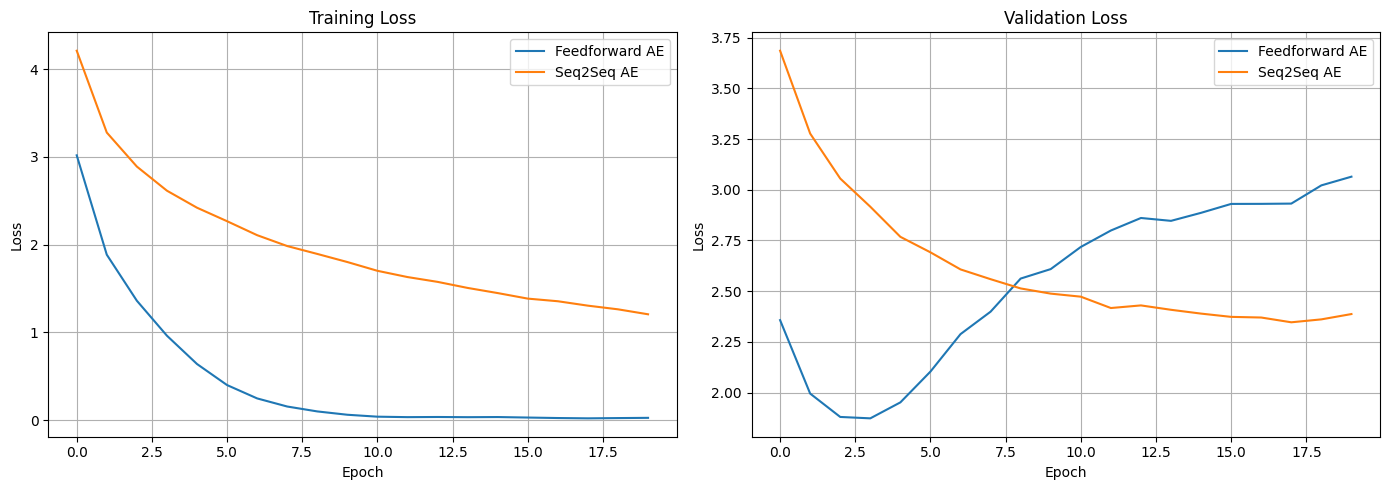

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(ff_history['train_loss'], label='Feedforward AE')
axes[0].plot(seq2seq_history['train_loss'], label='Seq2Seq AE')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(ff_history['val_loss'], label='Feedforward AE')
axes[1].plot(seq2seq_history['val_loss'], label='Seq2Seq AE')
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [74]:
def reconstruct_sentence(model, input_sentence, lang, seq2seq=False):
    input_tensor = tensorFromSentence(lang, input_sentence).squeeze()

    # Pad or truncate to MAX_LENGTH
    if len(input_tensor) < MAX_LENGTH:
        padding = torch.full(
            (MAX_LENGTH - len(input_tensor),),
            PAD_token,
            dtype=torch.long,
            device=input_tensor.device
        )
        input_tensor = torch.cat([input_tensor, padding])

    input_tensor = input_tensor[:MAX_LENGTH]

    # Add batch dimension
    input_tensor = input_tensor.unsqueeze(0)
    with torch.no_grad():
        if seq2seq:
            outputs = model.decoder(*model.encoder(input_tensor), None, teacher_forcing_ratio=0.0)[0]
            _, topi = outputs.topk(1)
            decoded_ids = topi.squeeze()
        else:
            logits = model(input_tensor)
            _, topi = logits.topk(1)
            decoded_ids = topi.squeeze()
    decoded_words = []
    for idx in decoded_ids:
        if idx.item() == EOS_token:
            decoded_words.append('<EOS>')
            break
        decoded_words.append(lang.index2word.get(idx.item(), '<UNK>'))
    return ' '.join(decoded_words)

print('Reconstruction examples:')
for i in range(5):
    inp, _ = random.choice(pairs)
    reconstructed_ff = reconstruct_sentence(ff_ae, inp, auto_input_lang, seq2seq=False)
    reconstructed_ss = reconstruct_sentence(seq2seq_ae, inp, auto_input_lang, seq2seq=True)
    print(f'Input: {inp}')
    print(f'Feedforward AE: {reconstructed_ff}')
    print(f'Seq2Seq AE:   {reconstructed_ss}')

Reconstruction examples:
Input: elles sont furieuses apres vous
Feedforward AE: <SOS> elles sont toutes bons vous amoureuses ils autre ici
Seq2Seq AE:   <SOS> ils sont de nous a se etre deux deux
Input: il est mignon dans son genre non ?
Feedforward AE: <SOS> il est mignon dans son genre non ? <EOS>
Seq2Seq AE:   <SOS> il est a pas a genre de ? <EOS>
Input: nous ne sommes pas en train de bouger
Feedforward AE: <SOS> nous ne sommes pas en train de parler <EOS>
Seq2Seq AE:   <SOS> nous ne sommes pas en train de <EOS>
Input: elle est capable de patiner
Feedforward AE: <SOS> elle est capable de tant riche comme ur rock
Seq2Seq AE:   <SOS> elle est sur a preparer faire des chaussures <EOS>
Input: je me demande si je l aime
Feedforward AE: <SOS> je me demande si je l toi toi <EOS>
Seq2Seq AE:   <SOS> je me demande si je je ai le francais
